In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [5]:
df = pd.read_csv("<put your path>", sep=None, engine="python")

df.head()

,city_resolvedAddress,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,...,event_type,event_start_time,event_end_time,event_start_hour,event_end_hour,event_day_date,event_start_hour_datetimeEpoch,event_end_hour_datetimeEpoch,event_hour_level_event_time,event_hour_level_event_datetimeEpoch
0,"Луцьк, Луцький район, Україна",2022-02-24,1645653600,4.9,0.7,2.6,0.0,83.7,0.118,4.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Луцьк, Луцький район, Україна",2022-02-24,1645653600,4.9,0.7,2.6,0.0,83.7,0.118,4.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Луцьк, Луцький район, Україна",2022-02-24,1645653600,4.9,0.7,2.6,0.0,83.7,0.118,4.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Луцьк, Луцький район, Україна",2022-02-24,1645653600,4.9,0.7,2.6,0.0,83.7,0.118,4.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Луцьк, Луцький район, Україна",2022-02-24,1645653600,4.9,0.7,2.6,0.0,83.7,0.118,4.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

event_hour_level_event_datetimeEpoch    608304
event_end_time                          608304
event_region_city                       608304
event_all_region                        608304
event_end                               608304
event_type                              608304
event_start_time                        608304
event_start                             608304
event_start_hour                        608304
event_end_hour_datetimeEpoch            608304
event_end_hour                          608304
event_hour_level_event_time             608304
event_day_date                          608304
event_start_hour_datetimeEpoch          608304
hour_preciptype                         543439
hour_visibility                         276458
hour_solarenergy                         87262
hour_uvindex                              4336
hour_solarradiation                       4336
day_uvindex                                552
dtype: int64

Temperature distribution

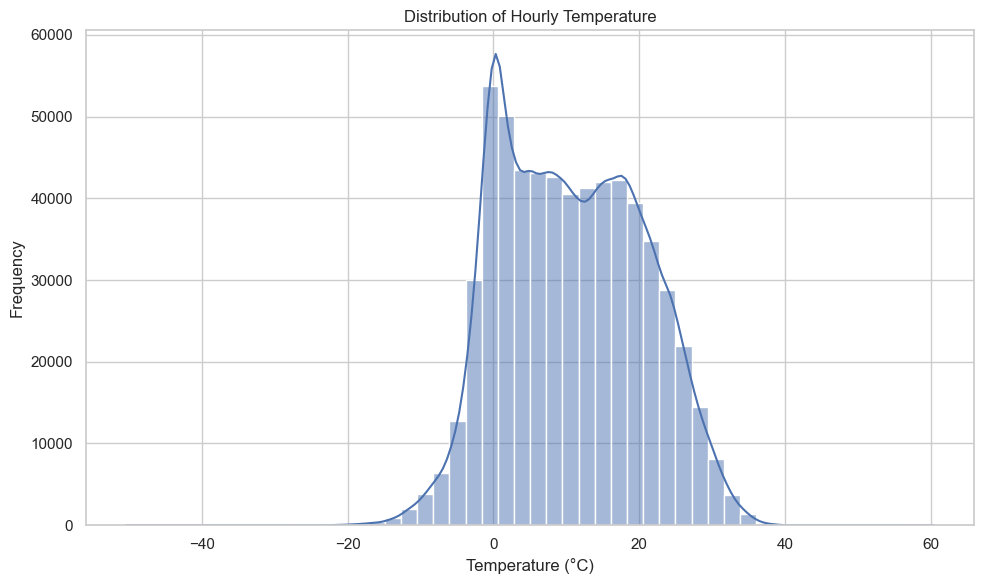

In [7]:
plt.figure()

sns.histplot(df["hour_temp"].dropna(), bins=50, kde=True)

plt.title("Distribution of Hourly Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Temperature vs Humidity

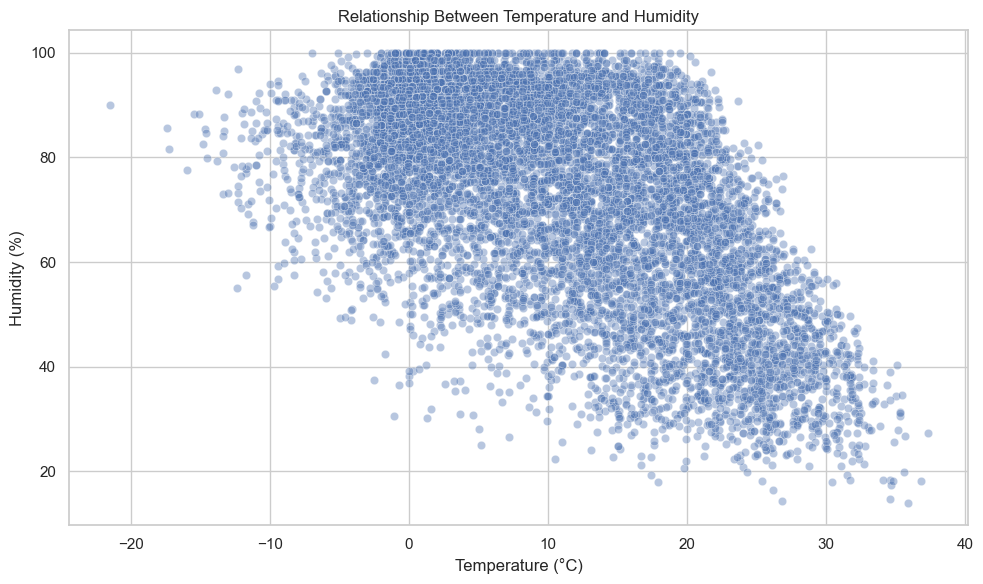

In [8]:
sample = df.sample(min(10000, len(df)))

plt.figure()

sns.scatterplot(
    x=sample["hour_temp"],
    y=sample["hour_humidity"],
    alpha=0.4
)

plt.title("Relationship Between Temperature and Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.tight_layout()
plt.show()

Weather conditions

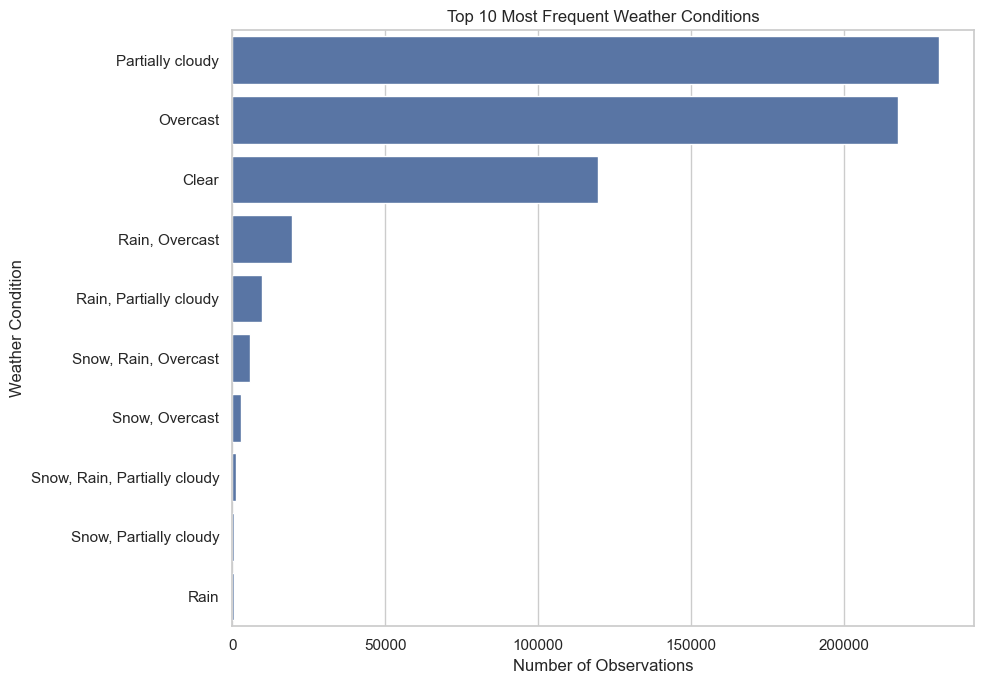

In [9]:
if "hour_conditions" in df.columns:

    conditions = df["hour_conditions"].value_counts().head(10)

    plt.figure(figsize=(10,7))

    sns.barplot(
        x=conditions.values,
        y=conditions.index,
        orient="h"
    )

    plt.title("Top 10 Most Frequent Weather Conditions")
    plt.xlabel("Number of Observations")
    plt.ylabel("Weather Condition")

    plt.tight_layout()
    plt.show()

Correlation heatmap

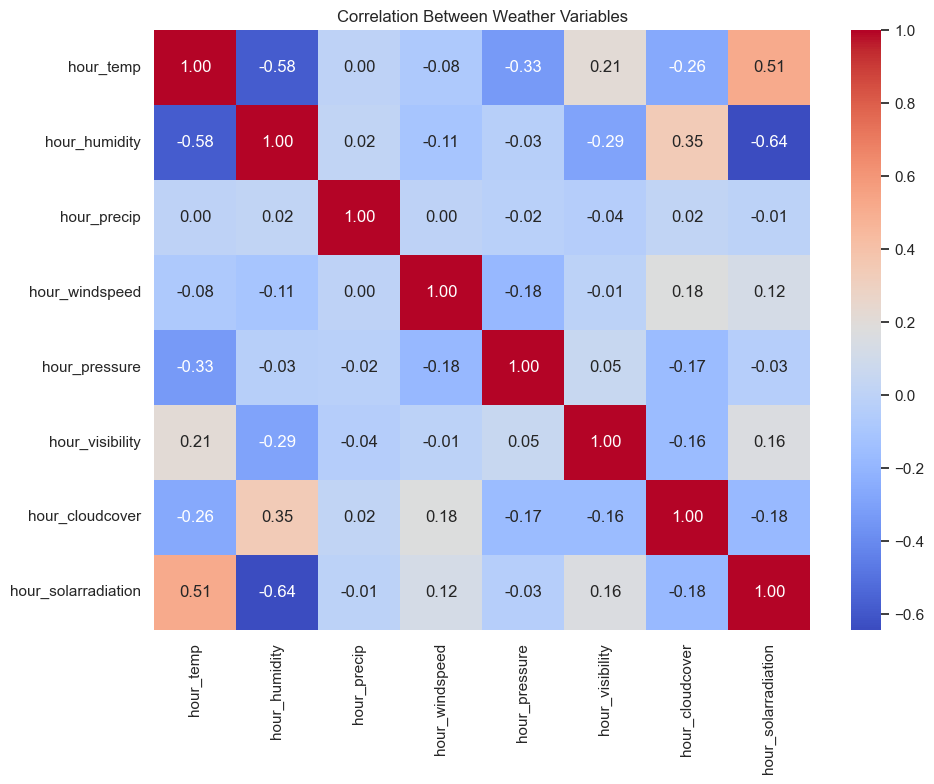

In [10]:
numeric_cols = [
    "hour_temp",
    "hour_humidity",
    "hour_precip",
    "hour_windspeed",
    "hour_pressure",
    "hour_visibility",
    "hour_cloudcover",
    "hour_solarradiation"
]

existing_cols = [c for c in numeric_cols if c in df.columns]

corr = df[existing_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Weather Variables")

plt.tight_layout()
plt.show()

PCA visualization

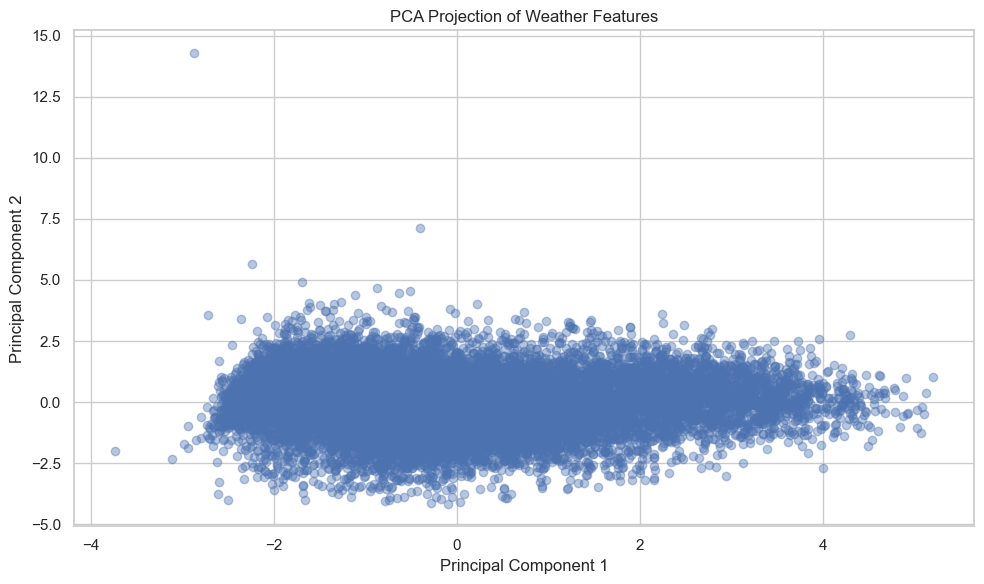

In [11]:
pca_data = df[existing_cols].dropna()

if len(pca_data) > 0:

    pca_data = pca_data.sample(min(15000, len(pca_data)))

    scaler = StandardScaler()
    scaled = scaler.fit_transform(pca_data)

    pca = PCA(n_components=2)
    components = pca.fit_transform(scaled)

    plt.figure()

    plt.scatter(
        components[:,0],
        components[:,1],
        alpha=0.4
    )

    plt.title("PCA Projection of Weather Features")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.tight_layout()
    plt.show()

else:
    print("Not enough data for PCA")

Time series trend

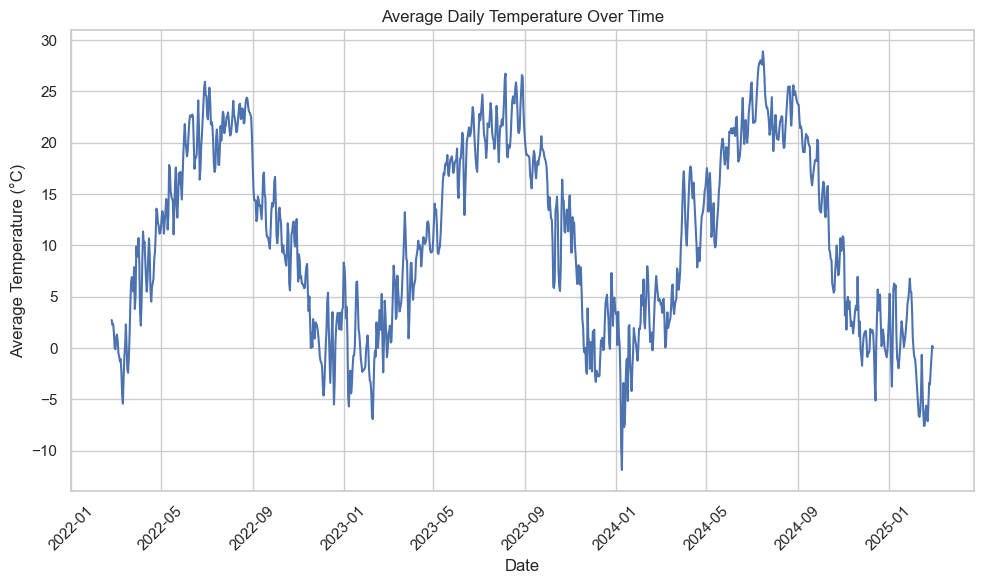

In [12]:
time_cols = [c for c in df.columns if "time" in c.lower()]

if len(time_cols) > 0:

    time_col = time_cols[0]

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

    time_df = df.dropna(subset=[time_col])

    if len(time_df) > 0:

        daily_temp = time_df.groupby(
            time_df[time_col].dt.date
        )["hour_temp"].mean()

        plt.figure()

        plt.plot(daily_temp.index, daily_temp.values)

        plt.title("Average Daily Temperature Over Time")
        plt.xlabel("Date")
        plt.ylabel("Average Temperature (°C)")

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

Event vs weather heatmap

In [13]:
if "event_start_hour" in df.columns and "hour_temp" in df.columns:

    heat_data = df.copy()

    heat_data["temp_bin"] = pd.cut(
        heat_data["hour_temp"],
        bins=10
    )

    pivot = heat_data.groupby(
        ["event_start_hour","temp_bin"]
    ).size().unstack()

    if pivot.size > 0:

        plt.figure(figsize=(12,6))

        sns.heatmap(
            pivot,
            cmap="YlOrRd"
        )

        plt.title("Event Frequency by Start Hour and Temperature Range")
        plt.xlabel("Temperature Range (°C)")
        plt.ylabel("Event Start Hour")

        plt.tight_layout()
        plt.show()

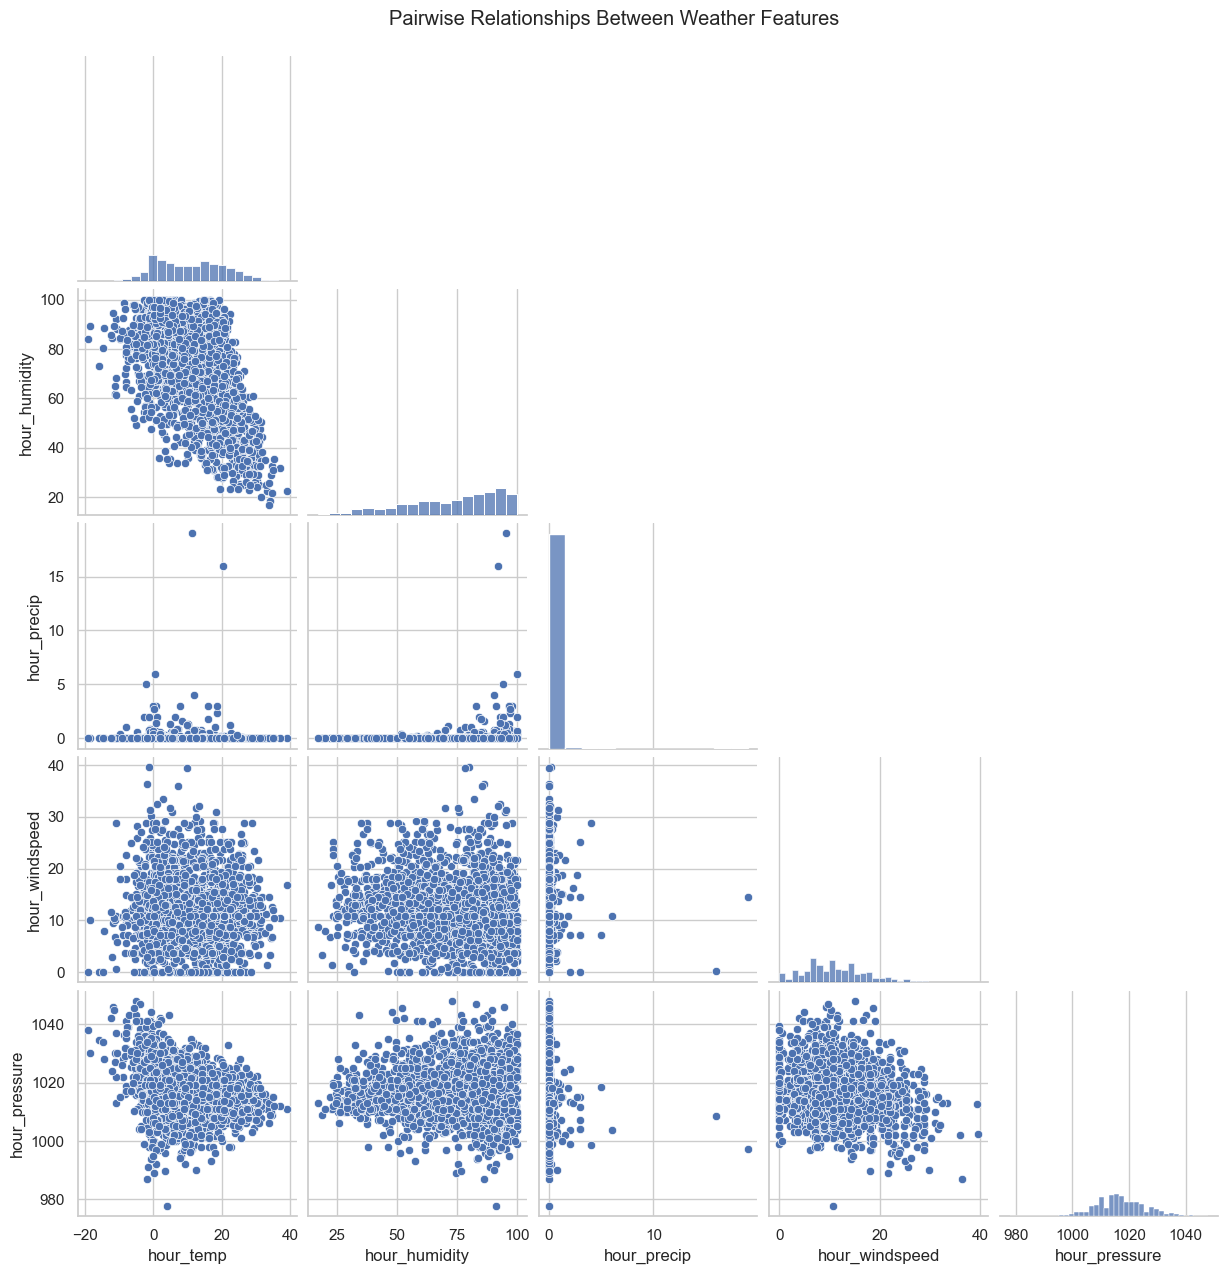

In [14]:
pair_cols = existing_cols[:5]

pair_data = df[pair_cols].dropna()

if len(pair_data) > 0:

    pair_data = pair_data.sample(min(2000, len(pair_data)))

    sns.pairplot(
        pair_data,
        corner=True
    )

    plt.suptitle(
        "Pairwise Relationships Between Weather Features",
        y=1.02
    )

    plt.show()